# 01 — Data Validation

Validate raw source files before building fact tables.

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid')
%matplotlib inline

## Exploritory Data Analysis

1. Can these datasets support a valid incrementality analysis?

In [2]:
# Load Raw Data
RAW = '../data/raw/'

In [3]:
# ==========================================
# EDA: Users
# ==========================================
 
dim_users = pd.read_csv(RAW + 'dim_users.csv')
print(f'dim_users: {dim_users.shape}')

#How many users exist?
print(dim_users['user_id'].nunique())

#What types of users exist?
segment_dist = (
    dim_users["customer_segment"]
    .value_counts(dropna=False)
    .to_frame("count")
)

segment_dist["pct"] = (
    segment_dist["count"]
    / segment_dist["count"].sum()
    * 100
).round(2)

display(segment_dist)

#What percentage are prospects?
    # 18% of users are prospects

#What percentage are lapsed subscribers?
    # 12% of users are lapsed subscribers

#What percentage are prior trial users?
    # 12% of users are prior trial users

# Prior subscriber distribution
subscriber_dist = (
    dim_users["prior_subscriber_flag"]
    .value_counts(dropna=False)
    .to_frame("count")
)

subscriber_dist["pct"] = (
    subscriber_dist["count"]
    / subscriber_dist["count"].sum()
    * 100
).round(2)

display(subscriber_dist)

# 34% of users are prior subscribers

# lapsed subscriber distribution
lapsed_dist = (
    dim_users["lapsed_subscriber_flag"]
    .value_counts(dropna=False)
    .to_frame("count")
)

lapsed_dist["pct"] = (
    lapsed_dist["count"]
    / lapsed_dist["count"].sum()
    * 100
).round(2)

display(lapsed_dist)

# Users are mostly acquision.

# Prior Trial Distribution
trial_dist = (
    dim_users["prior_trial_flag"]
    .value_counts(dropna=False)
    .to_frame("count")
)

trial_dist["pct"] = (
    trial_dist["count"]
    / trial_dist["count"].sum()
    * 100
).round(2)

display(trial_dist)

# 33% of users are prior trial users.

# Age Distribution
age_dist = (
    dim_users["age_band"]
    .value_counts(dropna=False)
    .to_frame("count")
)

age_dist["pct"] = (
    age_dist["count"]
    / age_dist["count"].sum()
    * 100
).round(2)

display(age_dist)

# Most users are between 25-34 years old and 35-44 years old

# Regional Distribution
region_dist = (
    dim_users["region"]
    .value_counts(dropna=False)
    .to_frame("count")
)

region_dist["pct"] = (
    region_dist["count"]
    / region_dist["count"].sum()
    * 100
).round(2)

display(region_dist.head(10))

# Most users are from the South


dim_users: (25000, 16)
25000


,count,pct
customer_segment,,
Casual Streamer,7338,29.35
New Prospect,4412,17.65
Premium Loyalist,3883,15.53
Trialist,2965,11.86
Lapsed Subscriber,2946,11.78
Heavy Streamer,1734,6.94
Win-back Target,1722,6.89


,count,pct
prior_subscriber_flag,,
0,16449,65.80
1,8551,34.20


,count,pct
lapsed_subscriber_flag,,
0,20332,81.33
1,4668,18.67


,count,pct
prior_trial_flag,,
0,16755,67.02
1,8245,32.98


,count,pct
age_band,,
25-34,6430,25.72
35-44,5279,21.12
18-24,3934,15.74
45-54,3909,15.64
55-64,2948,11.79
65+,2227,8.91
NaN,273,1.09


,count,pct
region,,
South,10147,40.59
West,5926,23.70
Midwest,4671,18.68
Northeast,3774,15.10
NaN,482,1.93


### Initial Observations

- Dataset contains 25,000 unique users.
- Largest customer segment is Casual Streamer at 29%.
- 34% of users were previous subscribers.
- 19% are lapsed subscribers.
- 33% have previously started a trial.
- Audience skews toward 18-34 age groups.
- Population appears realistic / unrealistic because yes, nothing jumps out as being unrealistic.

Overall, the dataset appears suitable for experiment design and causal inference analysis. I would just call out why the Premium Loyalists and Heavy Streamers, why are they being targeted in an acquisition campaign?

In [6]:
# ==========================================
# EDA: Ad Events
# ==========================================
raw_ad_events = pd.read_csv(RAW + 'raw_ad_events.csv')
print(f'raw_ad_events: {raw_ad_events.shape}')

# How large is the dataset?
print("Total ad event rows:", len(raw_ad_events))
print("Unique users with ad events:", raw_ad_events["user_id"].nunique())
print("Unique campaigns:", raw_ad_events["campaign_id"].nunique())
print("Unique creatives:", raw_ad_events["creative_id"].nunique())
print("Platforms:", raw_ad_events["platform"].nunique())

# What is the campaign date range?
raw_ad_events["timestamp"] = pd.to_datetime(raw_ad_events["timestamp"])

print("First ad event:", raw_ad_events["timestamp"].min())
print("Last ad event:", raw_ad_events["timestamp"].max())

daily_ad_events = (
    raw_ad_events
    .assign(date=raw_ad_events["timestamp"].dt.date)
    .groupby("date")
    .size()
    .reset_index(name="ad_events")
)

display(daily_ad_events.head())
display(daily_ad_events.tail())


# Platform distribution
platform_dist = (
    raw_ad_events
    .groupby("platform")
    .agg(
        ad_events=("event_id", "count"),
        users_reached=("user_id", "nunique"),
        impressions=("impression_flag", "sum"),
        clicks=("click_flag", "sum"),
        video_starts=("video_start_flag", "sum"),
        video_completes=("video_complete_flag", "sum")
    )
    .reset_index()
)

platform_dist["pct_ad_events"] = (
    platform_dist["ad_events"] / platform_dist["ad_events"].sum() * 100
).round(2)

platform_dist["ctr"] = (
    platform_dist["clicks"] / platform_dist["impressions"] * 100
).round(2)

platform_dist["video_completion_rate"] = (
    platform_dist["video_completes"] / platform_dist["video_starts"] * 100
).round(2)

display(platform_dist.sort_values("ad_events", ascending=False))

# How uneven is exposure frequency by user?
user_frequency = (
    raw_ad_events
    .groupby("user_id")
    .agg(
        total_ad_events=("event_id", "count"),
        total_impressions=("impression_flag", "sum"),
        total_clicks=("click_flag", "sum"),
        total_video_completes=("video_complete_flag", "sum"),
        first_exposure=("timestamp", "min"),
        last_exposure=("timestamp", "max")
    )
    .reset_index()
)

display(user_frequency["total_impressions"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

frequency_buckets = pd.cut(
    user_frequency["total_impressions"],
    bins=[0,10,20,40,60,80,100,float("inf")],
    labels=[
        "1-10",
        "11-20",
        "21-40",
        "41-60",
        "61-80",
        "81-100",
        "100+"
    ]
)

freq_dist = (
    frequency_buckets
    .value_counts()
    .sort_index()
    .to_frame("users")
)

freq_dist["pct"] = (
    freq_dist["users"] / freq_dist["users"].sum() * 100
).round(2)

display(freq_dist)

# Are there users in ad_users that are not in dim_users?
ad_users = set(raw_ad_events["user_id"].dropna().unique())
dim_user_ids = set(dim_users["user_id"].dropna().unique())

missing_from_dim = ad_users - dim_user_ids

print("Ad users not found in dim_users:", len(missing_from_dim))
print("Percent of ad-exposed users missing from dim_users:",
      round(len(missing_from_dim) / len(ad_users) * 100, 2))

raw_ad_events: (341675, 11)
Total ad event rows: 341675
Unique users with ad events: 9718
Unique campaigns: 9
Unique creatives: 25
Platforms: 5
First ad event: 2024-04-01 00:00:04
Last ad event: 2024-04-29 23:59:51


,date,ad_events
0,2024-04-01,10647
1,2024-04-02,11139
2,2024-04-03,11338
3,2024-04-04,11638
4,2024-04-05,11898


,date,ad_events
24,2024-04-25,11522
25,2024-04-26,11876
26,2024-04-27,13449
27,2024-04-28,13414
28,2024-04-29,1715


,platform,ad_events,users_reached,impressions,clicks,video_starts,video_completes,pct_ad_events,ctr,video_completion_rate
1,Meta,91964,9621,91964,1601,57185,12034,26.92,1.74,21.04
0,CTV,85344,9605,85344,0,82736,75634,24.98,0.00,91.42
4,YouTube,72010,9524,72010,1045,61158,25079,21.08,1.45,41.01
3,TikTok,61762,9453,61762,1585,47857,14267,18.08,2.57,29.81
2,Programmatic Display,30595,8652,30595,267,0,0,8.95,0.87,NaN


count   9,718.00
mean       35.16
std        21.80
min         9.00
25%        19.00
50%        28.00
75%        47.00
90%        66.00
95%        76.00
99%       104.00
max       200.00
Name: total_impressions, dtype: float64

,users,pct
total_impressions,,
1-10,1416,14.57
11-20,1938,19.94
21-40,3371,34.69
41-60,1948,20.05
61-80,706,7.26
81-100,219,2.25
100+,120,1.23


Ad users not found in dim_users: 0
Percent of ad-exposed users missing from dim_users: 0.0


## raw_ad_events Initial Observations

- The ad events table contains 34,1675 rows across 9,718 unique exposed users.
- Campaign activity runs from 2024-04-01 to 2024-04-29.
- The highest-volume platform is Meta.
- Exposure frequency is / is not evenly distributed across users.
- The 90th percentile user received 66% of impressions.
- There are 0 ad-exposed users missing from dim_users.
- The table appears suitable for building user-level exposure features.


Additionally, The user-level exposure distribution suggests frequency may play an important role in conversion outcomes and should be investigated during later lift analysis.


raw_subscription_events: (3650, 8)


,count,pct
status,,
active,2296,62.90
canceled,806,22.08
trial,361,9.89
suspended,178,4.88
NaN,9,0.25


Total subscriptions: 3650
Unique subscribed users: 3650
First subscription: 2021-08-01 00:00:00
Last subscription: 2024-06-08 00:00:00


,count,pct
plan_type,,
monthly,2126,58.25
quarterly,772,21.15
yearly,735,20.14
NaN,17,0.47


,subscription_start_date,subscriptions
11,2022-07,110
12,2022-08,89
13,2022-09,98
14,2022-10,114
15,2022-11,88
16,2022-12,119
17,2023-01,119
18,2023-02,122
19,2023-03,123
20,2023-04,93


status
active      63.06
canceled    22.14
trial        9.91
suspended    4.89
Name: proportion, dtype: float64

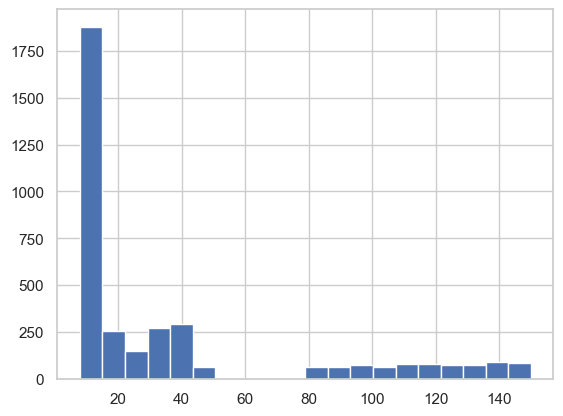

In [62]:
# ==========================================
# EDA: Subscription Events
# ==========================================
raw_subscription_events = pd.read_csv(RAW + 'raw_subscription_events.csv')
print(f'raw_subscription_events: {raw_subscription_events.shape}')

raw_subscription_events.columns.tolist()

# What subscription statuses exist?
status_dist = (
    raw_subscription_events["status"]
    .value_counts(dropna=False)
    .to_frame("count")
)

status_dist["pct"] = (
    status_dist["count"]
    / status_dist["count"].sum()
    * 100
).round(2)

display(status_dist)

# How many users subsscribed?
print(
    "Total subscriptions:",
    len(raw_subscription_events)
)

print(
    "Unique subscribed users:",
    raw_subscription_events["user_id"].nunique()
)

# What is the subscription date range?
raw_subscription_events["subscription_start_date"] = pd.to_datetime(
    raw_subscription_events["subscription_start_date"]
)

print(
    "First subscription:",
    raw_subscription_events["subscription_start_date"].min()
)

print(
    "Last subscription:",
    raw_subscription_events["subscription_start_date"].max()
)

# What plans are most popular?
plan_dist = (
    raw_subscription_events["plan_type"]
    .value_counts(dropna=False)
    .to_frame("count")
)

plan_dist["pct"] = (
    plan_dist["count"]
    / plan_dist["count"].sum()
    * 100
).round(2)

display(plan_dist)

# What is the distribution of plan values?
raw_subscription_events["plan_amount"].describe()

raw_subscription_events["plan_amount"].hist(
    bins=20
)

# How many new subscriptions occure each month?
monthly_subscriptions = (
    raw_subscription_events
    .groupby(
        raw_subscription_events[
            "subscription_start_date"
        ].dt.to_period("M")
    )
    .size()
    .reset_index(name="subscriptions")
)

display(
    monthly_subscriptions.tail(24)
)

# What percentage of scubscriptions are still active?
status_summary = (
    raw_subscription_events["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(status_summary)

The conversion rate falls within a believable range for a streaming acquisition business.

The dataset contains a large population of non-converters, which creates a realistic outcome variable for incrementality testing.

In [48]:
# ==========================================
# EDA: Spend Events
# ==========================================
raw_spend_events = pd.read_csv(RAW + 'raw_spend_events.csv')
print(f'raw_spend_events: {raw_spend_events.shape}')

# Total Spend

raw_spend_events.head()

total_spend = raw_spend_events['spend'].sum()
print(f'Total Spend: ${total_spend:,.2f}')

# Spend by Channel
spend_by_channel = (
    raw_spend_events
    .groupby('platform')
    .agg(total_spend=('spend', 'sum'))
)
print(spend_by_channel)

# Spend Distribution
spend_dist = raw_spend_events.groupby([ 'platform',  'impressions_purchased'])['spend'].sum().reset_index()
print(spend_dist)


# Do CPMs look realistic?
platform_spend = (
    raw_spend_events
    .groupby("platform")
    .agg(
        spend=("spend", "sum"),
        impressions=("impressions_purchased", "sum")
    )
)

platform_spend["cpm"] = (
    platform_spend["spend"]
    / platform_spend["impressions"]
    * 1000
).round(2)

display(platform_spend)

raw_spend_events: (245, 5)
Total Spend: $8,145,741.87
                      total_spend
platform                         
CTV                  2,747,606.33
Meta                 1,779,541.32
Programmatic Display   613,667.59
TikTok               1,249,739.49
YouTube              1,755,187.14
    platform  impressions_purchased     spend
0        CTV                 224362  6,855.33
1        CTV                 326233  9,968.00
2        CTV                 347887 10,629.63
3        CTV                 377182 11,524.72
4        CTV                 383900 11,729.98
..       ...                    ...       ...
240  YouTube                4429268 51,167.00
241  YouTube                4442732 51,322.54
242  YouTube                4508563 52,083.01
243  YouTube                4630140 53,487.48
244  YouTube                4795644 55,399.38

[245 rows x 3 columns]


,spend,impressions,cpm
platform,,,
CTV,"2,747,606.33",85108082,32.28
Meta,"1,779,541.32",187305603,9.50
Programmatic Display,"613,667.59",181468398,3.38
TikTok,"1,249,739.49",173630254,7.20
YouTube,"1,755,187.14",152704734,11.49


## raw_spend_events Initial Observations

The campaign invested approximately $8.15M across five advertising platforms.

CTV received the largest share of investment ($2.75M), followed by Meta ($1.78M) and YouTube ($1.76M). Programmatic Display received the lowest level of spend ($0.61M).

The spend data appears complete and suitable for campaign efficiency analysis.

This table will later be used to calculate Incremental Cost per Acquisition (iCPA) and evaluate whether observed lift justified media investment.

In [52]:
# Import dim_campaigns dataset
dim_campaigns = pd.read_csv(RAW + 'dim_campaigns.csv')
print(f'dim_campaigns: {dim_campaigns.shape}')

dim_campaigns.head

dim_campaigns: (9, 7)


<bound method NDFrame.head of   campaign_id                          campaign_name    objective  start_date  \
0      CMP001                  Q2 Acquisition - Meta  Acquisition  2024-04-01   
1      CMP002                Q2 Acquisition - TikTok  Acquisition  2024-04-01   
2      CMP003               Q2 Acquisition - YouTube  Acquisition  2024-04-01   
3      CMP004                   Q2 Acquisition - CTV  Acquisition  2024-04-01   
4      CMP005  Q2 Acquisition - Programmatic Display  Acquisition  2024-04-01   
5      CMP006         Always-On Retargeting - Social  Retargeting  2024-03-22   
6      CMP007              Brand Awareness - YouTube    Awareness  2024-04-01   
7      CMP008            Always-On Retargeting - CTV  Retargeting  2024-03-27   
8      CMP009             Prospecting - TikTok Spark  Acquisition  2024-04-08   

     end_date              platform   budget  
0  2024-04-28                  Meta  1450000  
1  2024-04-28                TikTok   980000  
2  2024-04-28     

In [47]:
dim_creatives = pd.read_csv(RAW + 'dim_creatives.csv')
print(f'dim_creatives: {dim_creatives.shape}')

dim_creatives['creative_name'].unique()

# How many creatives
#print(f'Number of creatives: {dim_creatives.shape[0]}')

dim_creatives: (25, 7)


<StringArray>
[    'MET_Trailer_001', 'MET_SocialProof_002',  'MET_OfferBased_003',
 'MET_CastFocused_004',     'TIK_Trailer_005', 'TIK_CastFocused_006',
 'TIK_SocialProof_007',  'TIK_OfferBased_008',     'YOU_Trailer_009',
     'YOU_Trailer_010', 'YOU_CastFocused_011', 'YOU_SocialProof_012',
  'YOU_OfferBased_013',     'CTV_Trailer_014',     'CTV_Trailer_015',
 'CTV_CastFocused_016', 'CTV_SocialProof_017',      'CTV_KeyArt_018',
      'PRO_KeyArt_019',      'PRO_KeyArt_020',  'PRO_OfferBased_021',
 'PRO_SocialProof_022',      'MET_KeyArt_023',      'TIK_KeyArt_024',
  'YOU_OfferBased_025']
Length: 25, dtype: str